In [66]:
# libraries for data manipulation
import pandas as pd
import numpy as np
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Loading datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
# Previewing the datasets
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
# Viewing column names, data types and missing values
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
# Checking dimensions
trades.shape

(211224, 16)

In [10]:
sentiment.shape

(2644, 4)

In [11]:
# Checking null values
trades.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
sentiment.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
# Checking duplicate values
trades.duplicated().sum()

np.int64(0)

In [15]:
sentiment.duplicated().sum()

np.int64(0)

# Coverting dates

In [17]:
# Converting Timestamp IST into datetime format
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"],format="%d-%m-%Y %H:%M")

In [18]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [19]:
# Converting date column into datetime format
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [20]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [24]:
# Extracting only the date from Timestamp IST
trades["date"] = trades["Timestamp IST"].dt.date

In [25]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [26]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [27]:
# Merge trading data with Fear & Greed Index using the date column
df=pd.merge(trades,sentiment,on="date",how="left")

In [28]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [29]:
# Checking dimensions
df.shape

(211224, 20)

In [30]:
# Checking missing values
df.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           6
value               6
classification      6
dtype: int64

In [31]:
# statistical summary 
df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,2.112180e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1.738301e+09,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1.740375e+09,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1.743572e+09,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,8.029302e+06,21.012784


In [32]:
# categorical summaries
df.describe(include="object")
# Helps understand unique categories such as
# Coin, Side and Classification.

,Account,Coin,Side,Direction,Transaction Hash,date,classification
count,211224,211224,211224,211224,211224,211224,211218
unique,32,246,2,12,101184,480,5
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,SELL,Open Long,0x00000000000000000000000000000000000000000000...,2025-02-25,Fear
freq,40184,68005,108528,49895,9032,6246,61837


In [33]:
# Creating a new feature which will indicate trade outcome
df["Trade Result"]=df["Closed PnL"].apply(lambda x:"Win" if x>0 else "Loss")
# Creating this feature simplifies the analysis
# of profitable and losing trades.

In [35]:
df["Trade Result"].head()

0    Loss
1    Loss
2    Loss
3    Loss
4    Loss
Name: Trade Result, dtype: object

# Average Profit by Market Sentiment

## Que.Does market sentiment affect the average profit earned by traders?

In [44]:
avg_profit=(df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False))

In [45]:
avg_profit.head()

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

C:\Users\aryan\AppData\Local\Temp\ipykernel_41640\544438772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_profit.index,


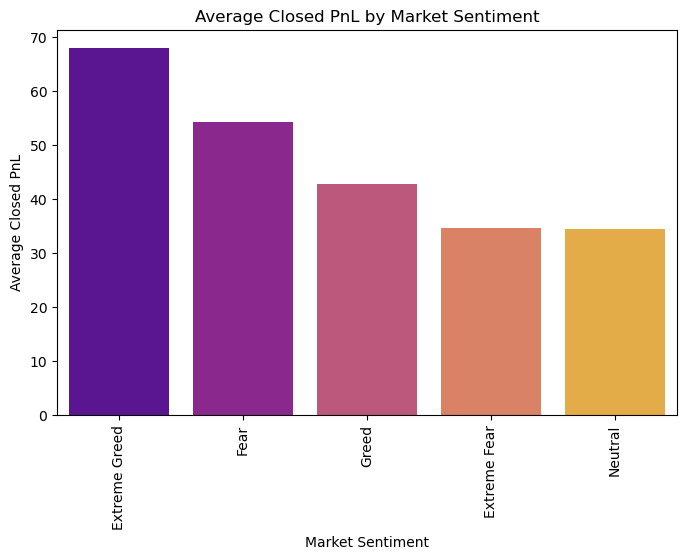

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(x=avg_profit.index,
    y=avg_profit.values,
    palette="plasma")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=90)

plt.show()

## Conclusion
## Traders generated the highest average profit during Extreme Greed, indicating that this market condition was more favorable for profitable trading.

# Total Profit by Market Sentiment

## Que.Which market sentiment generated the highest overall profit?

In [48]:
total_profit = (df.groupby("classification")["Closed PnL"].sum().sort_values(ascending=False))
total_profit.head()

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64

C:\Users\aryan\AppData\Local\Temp\ipykernel_41640\731739984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


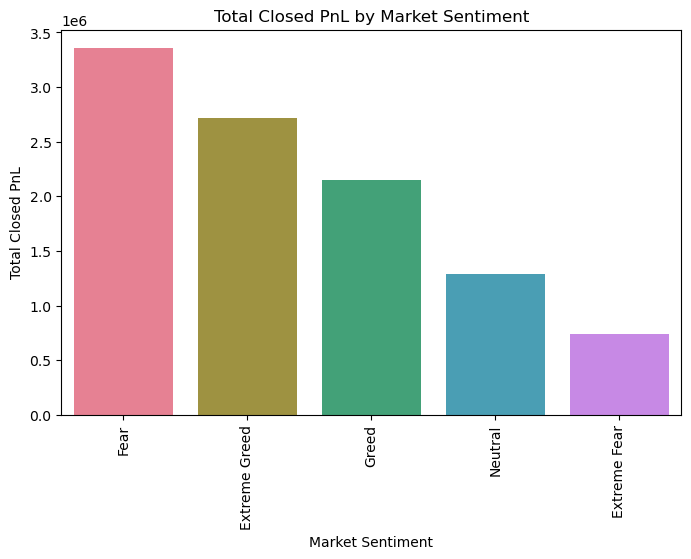

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=total_profit.index,
    y=total_profit.values,
    palette="husl")

plt.title("Total Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=90)

plt.show()

## Conclusion
## The majority of cumulative trading profits were generated during Fear, suggesting stronger market opportunities under this sentiment.

# Number of Trades
## Que.During which market sentiment were the most trades executed?

In [50]:
trade_count = (df.groupby("classification")["Closed PnL"].count().sort_values(ascending=False))
trade_count.head()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: Closed PnL, dtype: int64

C:\Users\aryan\AppData\Local\Temp\ipykernel_41640\272882990.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trade_count.index,y=trade_count.values,palette="viridis")


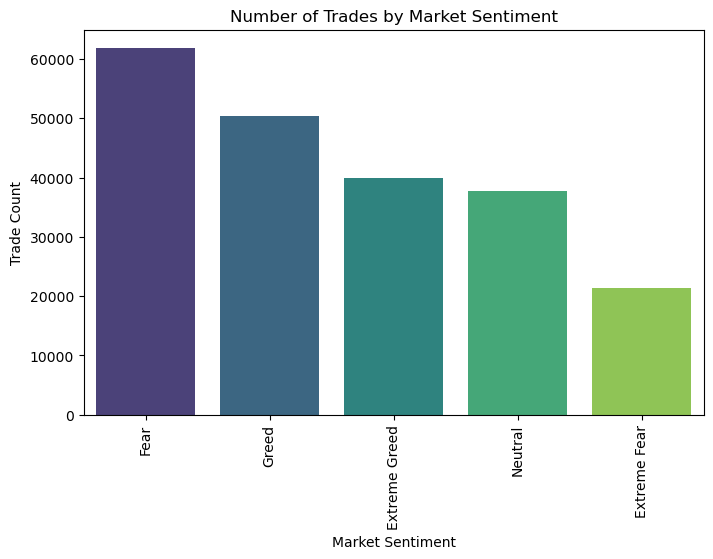

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(x=trade_count.index,y=trade_count.values,palette="viridis")

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=90)

plt.show()

# Maximum Profit

In [52]:
max_profit = (df.groupby("classification")["Closed PnL"].max())
max_profit.head()

classification
Extreme Fear     115287.00000
Extreme Greed     44223.45187
Fear             135329.09010
Greed             74530.52371
Neutral           48504.09555
Name: Closed PnL, dtype: float64

C:\Users\aryan\AppData\Local\Temp\ipykernel_41640\4054307329.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


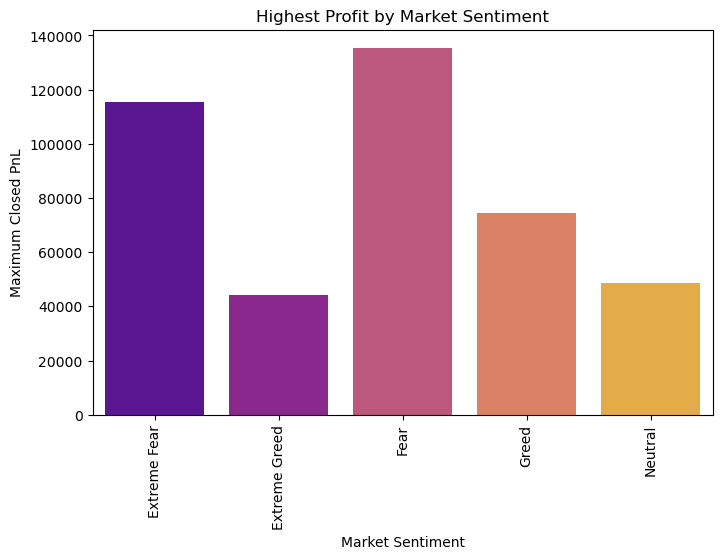

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=max_profit.index,
    y=max_profit.values,
    palette="plasma")

plt.title("Highest Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Maximum Closed PnL")
plt.xticks(rotation=90)

plt.show()

## Conclusion
## The largest individual profit was recorded during Fear, indicating the potential for exceptional returns in this market environment.

# Maximum Loss

In [55]:
max_loss = (df.groupby("classification")["Closed PnL"].min())
max_loss.head()

classification
Extreme Fear     -31036.69194
Extreme Greed    -10259.46800
Fear             -35681.74723
Greed           -117990.10410
Neutral          -24500.00000
Name: Closed PnL, dtype: float64

C:\Users\aryan\AppData\Local\Temp\ipykernel_41640\1189347943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


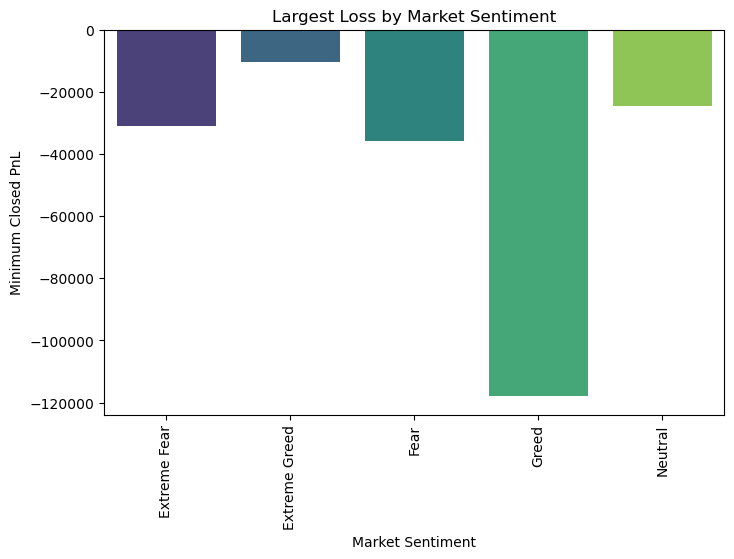

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=max_loss.index,
    y=max_loss.values,
    palette="viridis")

plt.title("Largest Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Minimum Closed PnL")
plt.xticks(rotation=90)
plt.show()


## Conclusion
## The most significant trading loss occurred during Greed, highlighting increased downside risk in this sentiment.

# Top 5 Best Performing Coin

In [84]:
top_5_coins = (
    df.groupby("Coin", as_index=False)["Closed PnL"]
      .sum()
      .sort_values(by="Closed PnL", ascending=False)
      .head(5))

top_5_coins

,Coin,Closed PnL
4,@107,2.783913e+06
137,HYPE,1.948485e+06
205,SOL,1.639556e+06
120,ETH,1.319979e+06
105,BTC,8.680447e+05


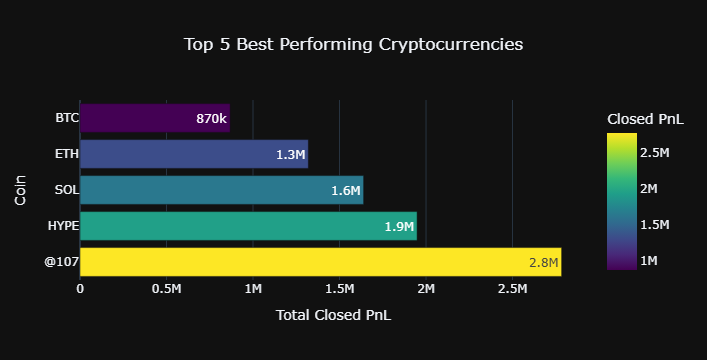

In [82]:
fig = px.bar(
    top_5_coins,
    x="Closed PnL",
    y="Coin",
    orientation="h",
    color="Closed PnL",
    text_auto=".2s",
    title="Top 5 Best Performing Cryptocurrencies",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Total Closed PnL",
    yaxis_title="Coin",
    template="plotly_dark"
)

fig.show()

## Conclusion
## The visualization highlights the top five cryptocurrencies ranked by cumulative trading profit. These assets generated the highest overall returns during the analysis period and may represent the most consistently profitable trading opportunities in the historical dataset.

# Que.Do larger trades generate higher profits?

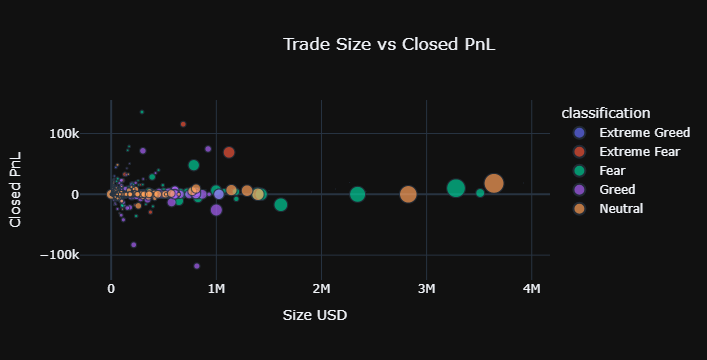

In [93]:
fig = px.scatter(
    df,
    x="Size USD",
    y="Closed PnL",
    color="classification",
    size=df["Fee"].abs(),   # ensure non-negative
    hover_data=["Coin", "Direction", "Account"],
    title="Trade Size vs Closed PnL"
)
fig.update_layout(
    template="plotly_dark",
    title_x=0.7
)

fig.show()


## Conclusion
## This scatter plot explores whether larger trade sizes are associated with higher profits or losses. The spread of points also highlights the variability in trading outcomes across different market sentiments.

# Market Sentiment Distribution

In [91]:
sentiment_count = (
    df.groupby("classification")
      .size()
      .reset_index(name="Trades"))
sentiment_count

,classification,Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


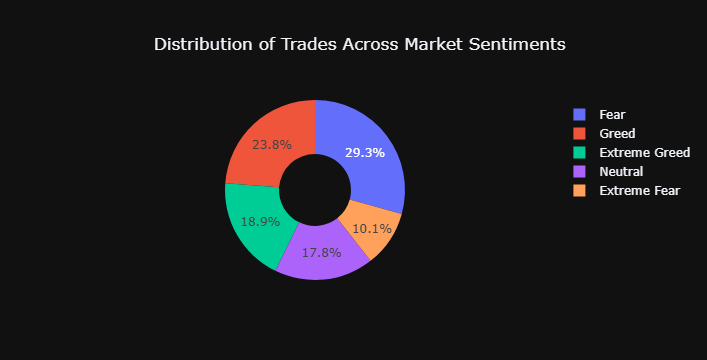

In [94]:
fig = px.pie(
    sentiment_count,
    values="Trades",
    names="classification",
    title="Distribution of Trades Across Market Sentiments",
    hole=0.4)

fig.update_layout(
    template="plotly_dark",
    title_x=0.8)

fig.show()

## Conclusion
## This chart shows the percentage of trades executed under each market sentiment, helping identify which market conditions were most common during the analysis period.

# Que.How does the distribution of trader profits vary across different market sentiments?

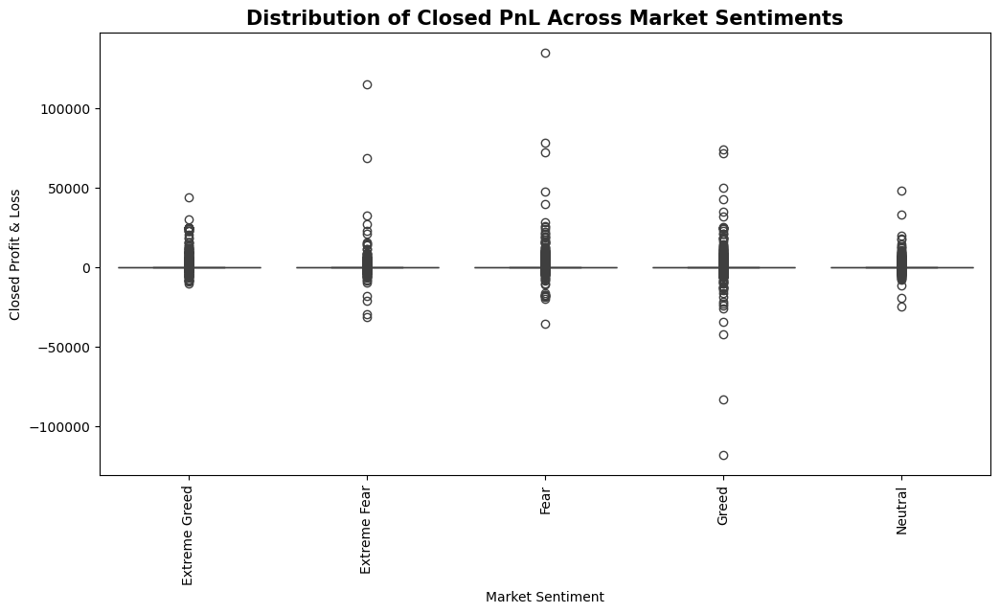

In [100]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="classification",
    y="Closed PnL")

plt.title("Distribution of Closed PnL Across Market Sentiments",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Market Sentiment")
plt.ylabel("Closed Profit & Loss")
plt.xticks(rotation=90)
plt.show()

## Conclusion
## The box plot compares the distribution of trader profits under different market sentiments. A wider box indicates greater variability in returns, while numerous outliers suggest the presence of unusually profitable or loss-making trades. This visualization helps assess both profitability and risk across market conditions.

# Correlation Heatmap
# How are numerical trading variables related to each other?

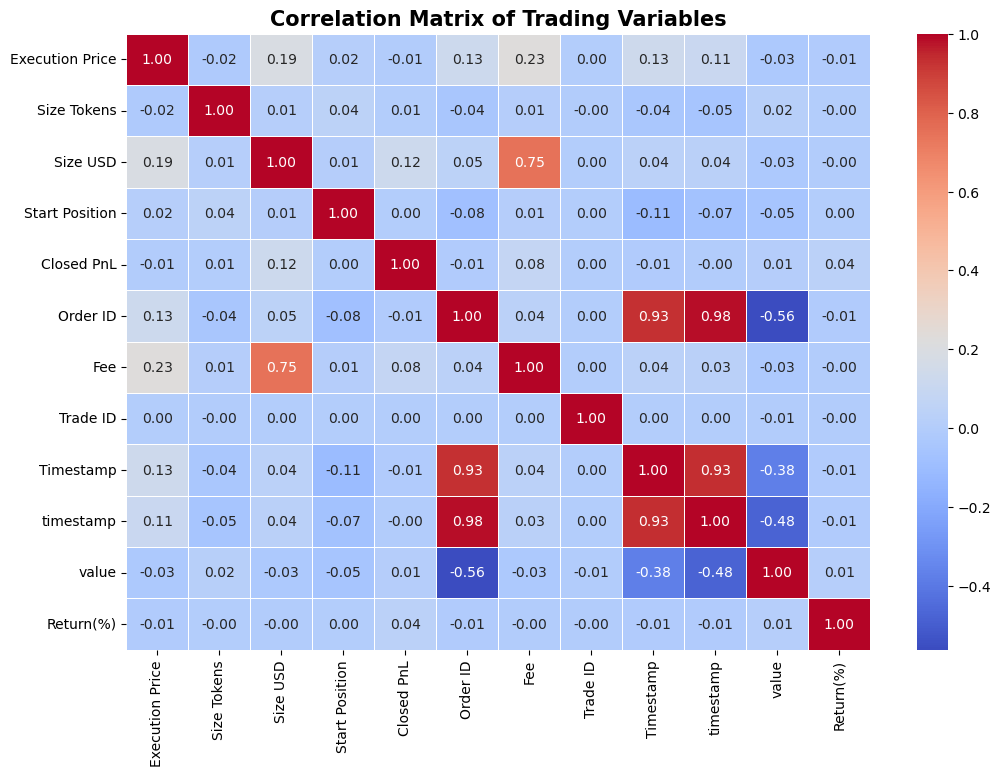

In [103]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5)

plt.title("Correlation Matrix of Trading Variables",
          fontsize=15,
          fontweight="bold")

plt.show()

## Conclusion
## The correlation heatmap reveals the strength and direction of relationships between numerical variables such as Closed PnL, Size USD, Fee, and Execution Price. Strong positive or negative correlations can help identify the factors most closely associated with trading performance.

# Project Conclusion
## Conclusion
This project examined the relationship between Bitcoin Market Sentiment (Fear & Greed Index) and historical trader performance by integrating sentiment data with Hyperliquid trading records. After cleaning, preprocessing, and merging the datasets, exploratory data analysis and interactive visualizations were used to identify key trends and patterns.The analysis showed that market sentiment influences trading behavior and performance. Metrics such as average profit, total profit, trade volume, transaction fees, trade size, and cryptocurrency performance varied across different sentiment categories, highlighting the impact of market psychology on trading decisions. Visualizations including bar charts, scatter plots, box plots, heatmaps, and pie charts provided valuable insights into profitability, risk, and asset performance.Overall, the findings suggest that market sentiment is a useful supporting indicator rather than a standalone trading signal. When combined with technical analysis and sound risk management, sentiment analysis can enhance decision-making. This project demonstrates practical skills in Python, Pandas, NumPy, Seaborn, Plotly, data preprocessing, and exploratory data analysis to derive actionable insights from financial datasets.